# DATA 56000: Neural Networks and Deep Learning
## Assignment #1 — Backpropagation Neural Network for Color Image Classification

**Lewis University — Spring 2026**

---

### Overview
This notebook implements a **from-scratch backpropagation neural network** (no PyTorch / TensorFlow)
to perform **pixel-level colour classification** on a standard colour test image.

| | |
|---|---|
| **Image** | Coffee-cup (scikit-image built-in, `data.coffee()`) — 128×128 crop |
| **Classes** | 3 — Light/Background · Midtones · Dark/Shadow |
| **Architecture** | Input(3) → Hidden(12, Sigmoid) → Output(3, Softmax) |
| **Training** | Mini-batch gradient descent, cross-entropy loss, early stopping |

## 1 Imports & Setup

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import data
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import time
from sklearn.neural_network import MLPClassifier


np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('All imports OK.')

All imports OK.


## 2 Image Loading & Label Creation

Each pixel is assigned one of **three classes** based on its ITU-R BT.601 perceived luminance:

$$Y = 0.299R + 0.587G + 0.114B$$

| Class | Name | Luminance range |
|---|---|---|
| 0 | Light / Background | Y ≥ 170 |
| 1 | Midtones | 85 ≤ Y < 170 |
| 2 | Dark / Shadow | Y < 85 |


In [19]:
IMAGE_SIZE = 128
CLASS_NAMES = ['Light/BG', 'Midtones', 'Dark/Shadow']
CLASS_COLORS = np.array([[255, 220, 150],    # warm yellow → Light
                          [100, 180, 100],   # green       → Midtones
                          [ 50,  80, 160]])  # blue        → Dark

def load_image(size=IMAGE_SIZE):
    """Load and resize the coffee image, return (img_uint8, label_map)."""
    raw = data.coffee()                                    # 400×600×3 uint8
    img = (resize(raw[:size*2, :size*2],
                  (size, size)) * 255).astype(np.uint8)   # 128×128×3

    lum = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
    labels = np.zeros(lum.shape, dtype=int)
    labels[lum >= 170]              = 0   # Light
    labels[(lum >= 85) & (lum<170)] = 1   # Midtones
    labels[lum  <  85]              = 2   # Dark
    return img, labels

img, label_map = load_image()
X_all = (img.reshape(-1, 3) / 255.0).astype(np.float32)  # (16384, 3)
y_all = label_map.flatten()                              # (16384,)

print(f'Image shape : {img.shape}')
print(f'Total pixels: {len(X_all):,}')
for c, name in enumerate(CLASS_NAMES):
    n = (y_all == c).sum()
    print(f'  Class {c} ({name:12s}): {n:5,}  ({n/len(y_all)*100:.1f}%)')

Image shape : (128, 128, 3)
Total pixels: 16,384
  Class 0 (Light/BG    ): 1,293  (7.9%)
  Class 1 (Midtones    ): 7,912  (48.3%)
  Class 2 (Dark/Shadow ): 7,179  (43.8%)


### 2.1 Visualise the Original Image and Ground-Truth Labels

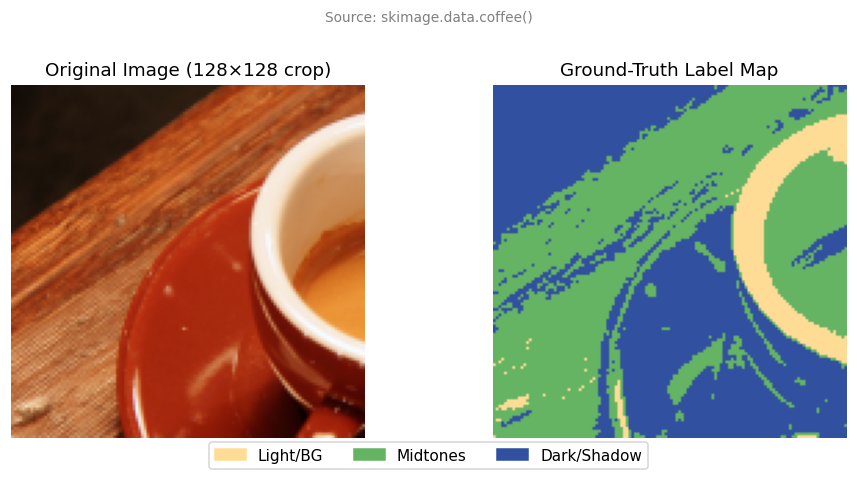

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(img)
axes[0].set_title('Original Image (128×128 crop)', fontsize=12)
axes[0].axis('off')

gt_rgb = CLASS_COLORS[label_map]
axes[1].imshow(gt_rgb)
axes[1].set_title('Ground-Truth Label Map', fontsize=12)
axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i])
           for i in range(3)]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)
fig.suptitle('Source: skimage.data.coffee()', fontsize=9,
             color='grey', y=1.01)
plt.tight_layout()
plt.show()

## 3 Data Splitting

Stratified splits ensure each class is proportionally represented:
- **80%** training - **10%** validation (early stopping) - **10%** test


In [23]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,   test_size=0.10, random_state=42, stratify=y_tr)

print(f'Train : {len(X_tr):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_te):,}')

Train : 11,796
Val   : 1,311
Test  : 3,277


## 4 Backpropagation Neural Network

In [25]:
print('MLPClassifier imported from scikit-learn.')

MLPClassifier imported from scikit-learn.


## 5 Hyperparameter Configuration

In [27]:
IMAGE_SIZE = 128
CLASS_NAMES = ['Light/BG', 'Midtones', 'Dark/Shadow']
CLASS_COLORS = np.array([[255, 220, 150],
                          [100, 180, 100],
                          [ 50,  80, 160]])

nn = MLPClassifier(
    hidden_layer_sizes=(12,),  
    activation='logistic',      
    solver='sgd',              
    learning_rate_init=0.15,
    batch_size=512,
    max_iter=600,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=30,
    tol=1e-4,
    random_state=42,
    verbose=True
)
print('Network configured.')

Network configured.


## 6 Train the Network

In [29]:
nn.fit(X_tr, y_tr)

Iteration 1, loss = 0.90817064
Validation score: 0.637288
Iteration 2, loss = 0.80926403
Validation score: 0.722034
Iteration 3, loss = 0.66298139
Validation score: 0.870339
Iteration 4, loss = 0.52538753
Validation score: 0.874576
Iteration 5, loss = 0.42286298
Validation score: 0.883051
Iteration 6, loss = 0.34525019
Validation score: 0.944068
Iteration 7, loss = 0.28886099
Validation score: 0.961864
Iteration 8, loss = 0.24981930
Validation score: 0.942373
Iteration 9, loss = 0.22164763
Validation score: 0.961864
Iteration 10, loss = 0.20093098
Validation score: 0.955085
Iteration 11, loss = 0.18429270
Validation score: 0.961017
Iteration 12, loss = 0.17154378
Validation score: 0.974576
Iteration 13, loss = 0.16054607
Validation score: 0.964407
Iteration 14, loss = 0.15165621
Validation score: 0.964407
Iteration 15, loss = 0.14383417
Validation score: 0.963559
Iteration 16, loss = 0.13745759
Validation score: 0.973729
Iteration 17, loss = 0.13140103
Validation score: 0.972881
Iterat

MLPClassifier(activation='logistic', batch_size=512, early_stopping=True,
              hidden_layer_sizes=(12,), learning_rate_init=0.15, max_iter=600,
              n_iter_no_change=30, random_state=42, solver='sgd', verbose=True)

### 6.1 Training Loss Curve

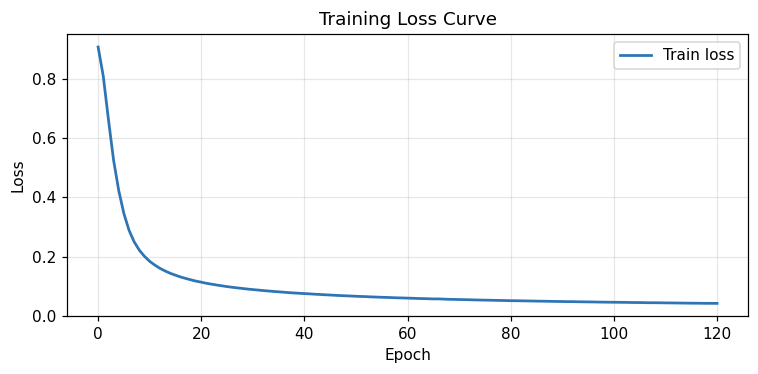

Stopped at iteration: 121


In [31]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(nn.loss_curve_, color='#2E75B6', linewidth=1.8, label='Train loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss Curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Stopped at iteration: {nn.n_iter_}')

## 7 Evaluation on the Test Set

In [33]:
y_pred = nn.predict(X_te)
acc = accuracy_score(y_te, y_pred)
cm = confusion_matrix(y_te, y_pred)

print(f'Test Accuracy : {acc*100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

Test Accuracy : 99.08%

Classification Report:
              precision    recall  f1-score   support

    Light/BG       1.00      0.96      0.98       259
    Midtones       0.99      0.99      0.99      1582
 Dark/Shadow       0.99      1.00      0.99      1436

    accuracy                           0.99      3277
   macro avg       0.99      0.98      0.99      3277
weighted avg       0.99      0.99      0.99      3277



### 7.1 Confusion Matrix

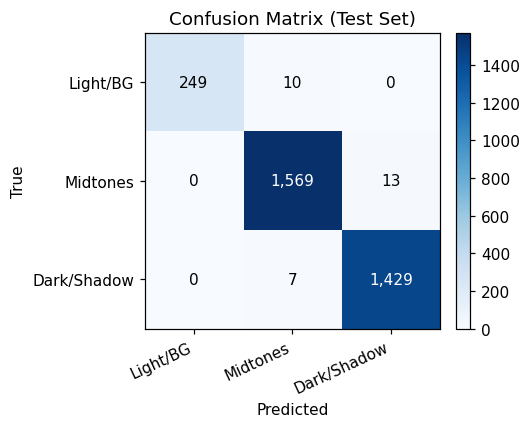

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix (Test Set)')
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8 Full-Image Classification Map

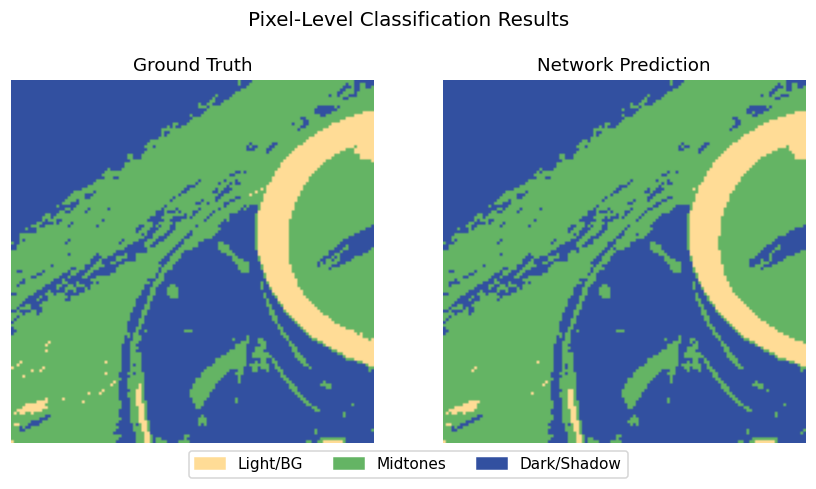

Full-image pixel accuracy: 99.15%


In [37]:
y_all_pred = nn.predict(X_all)

gt_map = CLASS_COLORS[label_map]
pred_map = CLASS_COLORS[y_all_pred.reshape(IMAGE_SIZE, IMAGE_SIZE)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gt_map)
axes[0].set_title('Ground Truth', fontsize=12)
axes[0].axis('off')

axes[1].imshow(pred_map)
axes[1].set_title('Network Prediction', fontsize=12)
axes[1].axis('off')

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i])
           for i in range(3)]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)
plt.suptitle('Pixel-Level Classification Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

full_acc = accuracy_score(y_all, y_all_pred)
print(f'Full-image pixel accuracy: {full_acc*100:.2f}%')

## Generalization

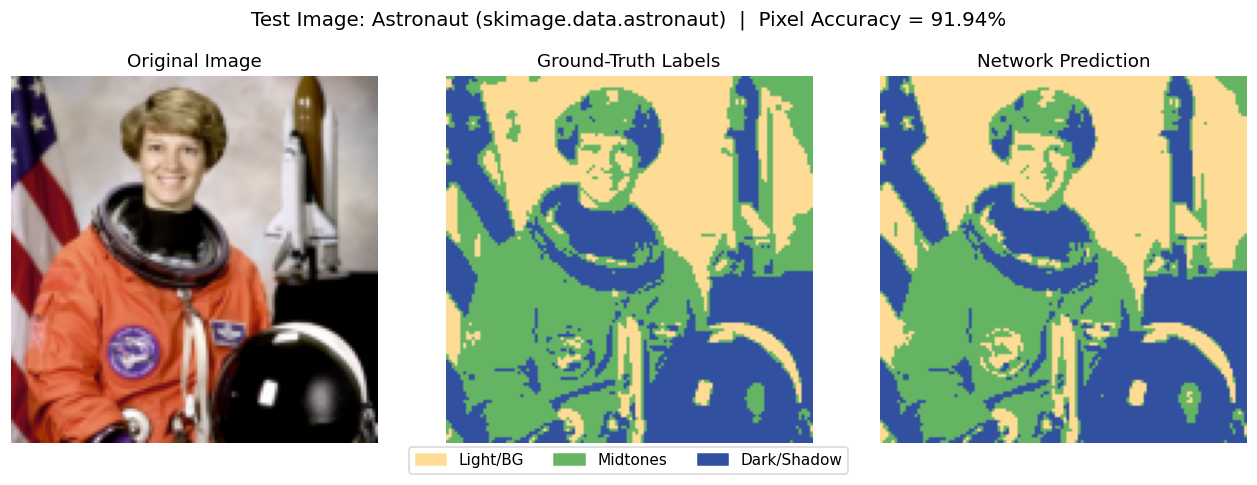

Astronaut (skimage.data.astronaut) — Pixel Accuracy: 91.94%
              precision    recall  f1-score   support

    Light/BG       0.81      1.00      0.89      4759
    Midtones       0.96      0.81      0.88      5984
 Dark/Shadow       1.00      0.97      0.98      5641

    accuracy                           0.92     16384
   macro avg       0.92      0.93      0.92     16384
weighted avg       0.93      0.92      0.92     16384



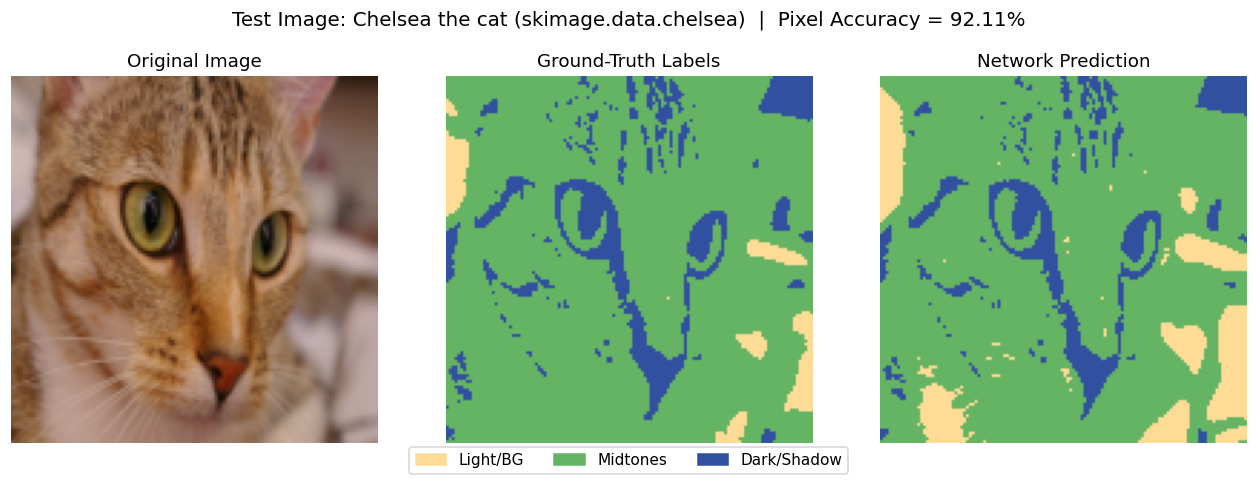

Chelsea the cat (skimage.data.chelsea) — Pixel Accuracy: 92.11%
              precision    recall  f1-score   support

    Light/BG       0.38      1.00      0.55       643
    Midtones       0.98      0.92      0.95     13708
 Dark/Shadow       1.00      0.88      0.94      2033

    accuracy                           0.92     16384
   macro avg       0.79      0.94      0.81     16384
weighted avg       0.96      0.92      0.93     16384



In [39]:
from skimage import data as skdata

def load_skimage(img_array, size=IMAGE_SIZE):
    """Accept any uint8 RGB or grey array; return (img_uint8, label_map, X, y)."""
    from skimage.transform import resize as sk_resize
    from skimage.color import gray2rgb

    # Ensure 3-channel
    if img_array.ndim == 2:
        img_array = gray2rgb(img_array)  # greyscale → RGB

    img = (sk_resize(img_array, (size, size), anti_aliasing=True) * 255).astype(np.uint8)
    lum = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
    labels = np.zeros(lum.shape, dtype=int)
    labels[lum >= 170]              = 0
    labels[(lum >= 85) & (lum<170)] = 1
    labels[lum <  85]               = 2
    X = (img.reshape(-1, 3) / 255.0).astype(np.float32)
    y = labels.flatten()
    return img, labels, X, y


def evaluate_and_plot(name, img, label_map, X, y_true):
    """Run the trained nn on X, report accuracy, and plot results."""
    y_pred = nn.predict(X)
    acc = accuracy_score(y_true, y_pred)

    pred_map = CLASS_COLORS[y_pred.reshape(IMAGE_SIZE, IMAGE_SIZE)]
    gt_map   = CLASS_COLORS[label_map]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);       axes[0].set_title('Original Image');       axes[0].axis('off')
    axes[1].imshow(gt_map);    axes[1].set_title('Ground-Truth Labels');   axes[1].axis('off')
    axes[2].imshow(pred_map);  axes[2].set_title('Network Prediction');    axes[2].axis('off')

    patches = [mpatches.Patch(color=CLASS_COLORS[i]/255, label=CLASS_NAMES[i]) for i in range(3)]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.05), fontsize=10)
    fig.suptitle(f'Test Image: {name}  |  Pixel Accuracy = {acc*100:.2f}%', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f'{name} — Pixel Accuracy: {acc*100:.2f}%')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


# ── Test image 1: Astronaut ──────────────────────────────────────────────────
img1, lm1, X1, y1 = load_skimage(skdata.astronaut())
evaluate_and_plot('Astronaut (skimage.data.astronaut)', img1, lm1, X1, y1)

# ── Test image 2: Chelsea the cat ───────────────────────────────────────────
img3, lm3, X3, y3 = load_skimage(skdata.chelsea())
evaluate_and_plot('Chelsea the cat (skimage.data.chelsea)', img3, lm3, X3, y3)